## Predictive and Risk Segmentation

In [22]:
import joblib
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

In [2]:
## Load the model
model_pack = joblib.load('../Artifacts/Model/telco_churn_final_model.pkl')

# Extract components
final_model = model_pack['model']
model_features = model_pack['features']

In [3]:
## Load clean data
data = pd.read_csv("..\\data\\processed\\cleaned_feature_engineering_telco_customer_churn.csv")

print(data.shape)
data.head()

(7021, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,-0.440278,1,0,-1.279910,0,0,0,1,0,...,-1.161010,-0.993745,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,-0.440278,0,0,0.064885,1,0,1,0,1,...,-0.260031,-0.172844,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,-0.440278,0,0,-1.239159,1,0,1,1,0,...,-0.363095,-0.959182,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,-0.440278,0,0,0.513151,0,0,1,0,1,...,-0.747091,-0.194364,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,-0.440278,0,0,-1.239159,1,0,0,0,0,...,0.197108,-0.939980,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
## Features and target
X = data.drop('Churn', axis=1)
y = data['Churn']

print(X.shape, y.shape)

(7021, 23) (7021,)


### 1. Can customers be classified into high, medium, low churn risk?

In [6]:
predict_probabilities = final_model.predict_proba(X)[:,1] # for class 1
predict_probabilities

array([0.72815104, 0.1233737 , 0.52048535, ..., 0.44070949, 0.81615971,
       0.31989691], shape=(7021,))

In [7]:
# Create a segmentation dataframe
risk_df = data
risk_df['Churn_Probability'] = predict_probabilities
risk_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Probability
0,0.0,-0.440278,1,0,-1.279910,0,0,0,1,0,...,-0.993745,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.728151
1,1.0,-0.440278,0,0,0.064885,1,0,1,0,1,...,-0.172844,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.123374
2,1.0,-0.440278,0,0,-1.239159,1,0,1,1,0,...,-0.959182,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.520485
3,1.0,-0.440278,0,0,0.513151,0,0,1,0,1,...,-0.194364,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.106155
4,0.0,-0.440278,0,0,-1.239159,1,0,0,0,0,...,-0.939980,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.832431


In [9]:
# Define risk tiers
def get_risk_tier(prob):
    if prob >= 0.7: return 'High Risk'
    elif prob >= 0.3: return 'Medium Risk'
    else: return 'Low Risk'

risk_df['Risk_Segment'] = risk_df['Churn_Probability'].apply(get_risk_tier)
risk_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Probability,Risk_Segment
0,0.0,-0.440278,1,0,-1.279910,0,0,0,1,0,...,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.728151,High Risk
1,1.0,-0.440278,0,0,0.064885,1,0,1,0,1,...,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.123374,Low Risk
2,1.0,-0.440278,0,0,-1.239159,1,0,1,1,0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.520485,Medium Risk
3,1.0,-0.440278,0,0,0.513151,0,0,1,0,1,...,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.106155,Low Risk
4,0.0,-0.440278,0,0,-1.239159,1,0,0,0,0,...,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.832431,High Risk


In [10]:
# Display distribution
print(risk_df['Risk_Segment'].value_counts())

Risk_Segment
Low Risk       3316
Medium Risk    2386
High Risk      1319
Name: count, dtype: int64


### 2. Which features are most important in predicting churn?

C:\Users\DELL\AppData\Local\Temp\ipykernel_5172\1134837874.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


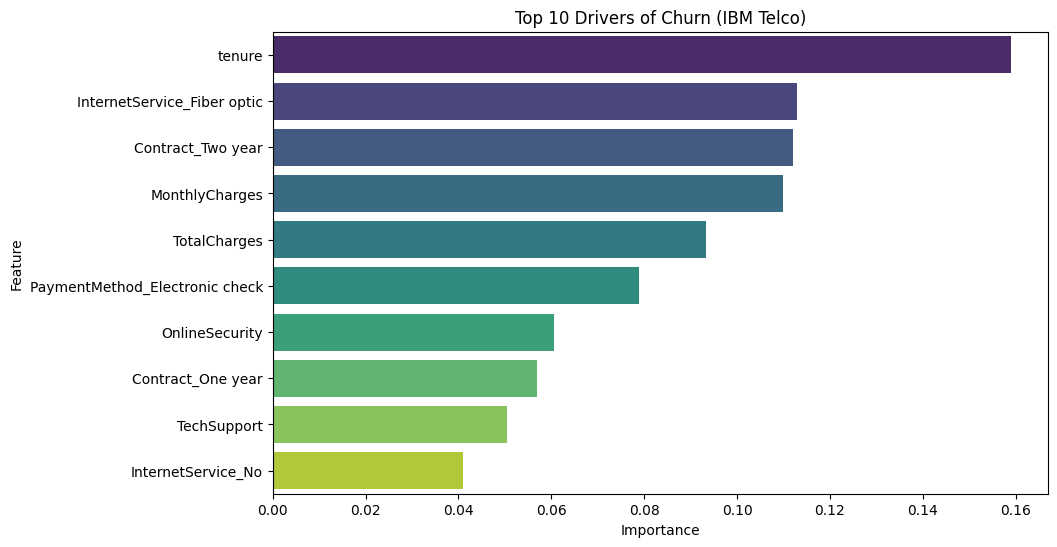

In [13]:
## Extract and sort importances
importances = final_model.feature_importances_
feat_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Drivers of Churn (IBM Telco)')
plt.show()

### 3. What is the churn probability for new customers?

In [18]:
## New sample customer
new_customer = X.iloc[:1,:]
new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,-0.440278,1,0,-1.27991,0,0,0,1,0,...,1,-1.16101,-0.993745,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [19]:
## Predicted probability
final_model.predict_proba(new_customer)

array([[0.27184896, 0.72815104]])

#### Insights:
The churn prediction of the customer 0 is 72%.

In [20]:
## Actual Class for this customer
y[0]

np.int64(0)

In [21]:
final_model.predict(new_customer)

array([1])

### 4. How accurate is the churn prediction model?

In [27]:
round(accuracy_score(y, final_model.predict(X)), 2)

0.8

The overall accuracy score is almost 80%.

### 5. How can prediction help targeted retention campaigns? 

1. High-Risk Segment: "Preventative Revenue Rescue"
Target: Customers with a Churn Probability > 70%.
Business Context: These customers likely exhibit behaviors such as being on a "Month-to-Month" contract with "Fiber Optic" issues or low tenure.
Action: Financial Incentives & Contract Conversion.
Deploy exclusive "Loyalty Pricing" to incentivize a transition from Month-to-Month to a 1-year or 2-year fixed contract.
Empower the Customer Success team to offer targeted "Plan Right-sizing" discounts, effectively "locking in" the customer before the predicted churn date.

2. Medium-Risk Segment: "Engagement & Stickiness"
Target: Customers with a Churn Probability between 30% and 70%.
Business Context: These customers are not yet certain to leave but show signs of low engagement or lack of "utility" features.
Action: Value-Added Education (Product Adoption).
Launch an automated email drip campaign providing "How-to" guides for features they haven't activated (e.g., Online Security, Tech Support, or Device Protection).
Research shows that customers using multiple "stickiness" services are significantly less likely to churn. This campaign aims to increase the "cost of switching" by making the service more integral to their daily lives.

3. Low-Risk Segment: "Value Expansion"
Target: Customers with a Churn Probability < 30%.
Business Context: These are stable, loyal customers with high tenure and multi-year contracts.
Action: Upsell & Referral Programs.
Avoid discounting for this group as it results in unnecessary "margin erosion."
Instead, target them for Up-selling (higher data tiers) or Referral Programs, turning loyalists into brand advocates to lower the cost of new customer acquisition.